In [18]:
#写一个大循环，循环不同的分辨率
# 匹配数目与平均降水
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
from cartopy.io.shapereader import Reader
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import BoundaryNorm
a=0.2
p = int(7 / a)
q = int(11 / a)

In [19]:
gauge_pre_grided=np.load('gauge_pre_grided.npy')
satellite_pre=np.load("precip_all_hour_satellite.npy")

In [20]:
gauge_pre_num=np.load("gauge_pre_num.npy")

In [21]:
gauge_pre_num.shape

(43848, 35, 55)

In [22]:
#添加误差
def func(x, a, b):
    return a * np.exp(-b * x)

def get_ab_values(rain):
    if rain < 2:
        return 0.45131016517318423, 0.16169399717438698
    elif 2 <= rain < 4:
        return  1.6794847980908945, 0.16198899816352366
    elif 4 <= rain < 8:
        return 3.437138732494024, 0.16260406256981108
    elif rain >= 8:
        return 7.550905959233764, 0.16581205841013613
    else:
        return -9999,-9999


In [23]:
gauge_pre_num.shape

(43848, 35, 55)

In [24]:
# 定义每年的小时数（已知两个闰年）
hours_per_year = [8784, 8760, 8760, 8760, 8784]

# 预计算各季节起始索引（基于每年1月1日0时为起点）
season_slices = [
    # 春季：3-5月（按闰年计算，实际使用时根据年份索引选择）
    {"start": 31*24 + 28*24, "end": 31*24 + 28*24 + 92*24},  # 3/1 0:00 ~ 5/31 23:00
    
    # 夏季：6-8月
    {"start": 31*24 + 28*24 + 92*24, "end": 31*24 + 28*24 + 92*24 + 92*24},
    
    # 秋季：9-11月
    {"start": 31*24 + 28*24 + 184*24, "end": 31*24 + 28*24 + 184*24 + 91*24},
    
    # 冬季：当年12月 + 次年1-2月（修正为仅当前年）
    {"start": 334*24, "end": 365*24},  # 12/1 0:00 ~ 12/31 23:00
    {"pre_start": 0, "pre_end": 59*24}  # 1/1 0:00 ~ 2/28 23:00
]

# 动态生成各年实际索引（考虑闰年）
def get_season_indices(year_idx, is_leap):
    base = sum(hours_per_year[:year_idx])
    leap_offset = 24 if is_leap else 0
    
    return {
        "spring": (
            base + (31*24 + 28*24 + leap_offset),  # 3/1 0:00
            base + (31*24 + 28*24 + 92*24 + leap_offset)
        ),
        "summer": (
            base + (31*24 + 28*24 + 92*24 + leap_offset),
            base + (31*24 + 28*24 + 184*24 + leap_offset)
        ),
        "autumn": (
            base + (31*24 + 28*24 + 184*24 + leap_offset),
            base + (31*24 + 28*24 + 275*24 + leap_offset)
        ),
        "winter": [
            (base + 334*24, base + (366 if is_leap else 365)*24),  # 12/1 ~ 年底
            (base, base + 59*24 + (24 if is_leap else 0))          # 1/1 ~ 2/29/28
        ]
    }


# 初始化季节数据容器
pre = [[] for _ in range(4)]
pre_up = [[] for _ in range(4)]
num = [[] for _ in range(4)]

# 处理每个年份的数据
cursor = 0
for year in range(5):
    is_leap = (hours_per_year[year] == 8784)
    indices = get_season_indices(year, is_leap)
    
    # 切割四季数据
    for i, season in enumerate(["spring", "summer", "autumn"]):
        start, end = indices[season]
        pre[i].append(gauge_pre_grided[start:end])
        pre_up[i].append(satellite_pre[start:end])
        num[i].append(gauge_pre_num[start:end])
    
    # 冬季特殊处理：12月 + 1-2月（同一年内）
    winter12 = gauge_pre_grided[indices["winter"][0][0]:indices["winter"][0][1]]
    winter1_2 = gauge_pre_grided[indices["winter"][1][0]:indices["winter"][1][1]]
    pre[3].append(np.concatenate([winter1_2, winter12]))
    
    sate_winter12 = satellite_pre[indices["winter"][0][0]:indices["winter"][0][1]]
    sate_winter1_2 = satellite_pre[indices["winter"][1][0]:indices["winter"][1][1]]
    pre_up[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

    sate_winter12 = gauge_pre_num[indices["winter"][0][0]:indices["winter"][0][1]]
    sate_winter1_2 = gauge_pre_num[indices["winter"][1][0]:indices["winter"][1][1]]
    num[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

In [25]:
#把五维list，转为四维，把年份的维度合并
pre_4d={}
pre_up_4d={}
num_4d={}
for i in range(4):
    pre_4d[i]=[]
    pre_up_4d[i]=[]
    num_4d[i]=[]
    for j in range(5):
        pre_4d[i].append(pre[i][j])
        pre_up_4d[i].append(pre_up[i][j])
        num_4d[i].append(num[i][j])
    pre_4d[i]=np.concatenate(pre_4d[i], axis=0)
    pre_up_4d[i]=np.concatenate(pre_up_4d[i], axis=0)
    num_4d[i]=np.concatenate(num_4d[i], axis=0)

In [26]:
pre[i][j].shape

(2208, 35, 55)

In [27]:
pre_4d[3].shape

(10896, 35, 55)

In [28]:
# wucha={}

# for s in range(4):#四个季节
#     print(s)
#     wucha[s]=np.full(pre_4d[s].shape,np.nan)
#     wucha[s+4]=np.full(pre_4d[s].shape,np.nan)
#     for t in range(len(pre_4d[s])):
#         pre_4d[s][(pre_4d[s]<0.1) & (pre_up_4d[s]<0.1)]=np.nan
#         pre_up_4d[s][(pre_4d[s]<0.1) & (pre_up_4d[s]<0.1)]=np.nan
#         for i in range(35):
#             for j in range(55):
#                 # if pre[s][t,i,j]<0.1 and pre_up[s][t,i,j]<0.1:
#                 #     continue
#                 if pre_4d[s][t,i,j]!=pre_4d[s][t,i,j] or pre_up_4d[s][t,i,j]!=pre_up_4d[s][t,i,j]:
#                     continue
#                 a,b=get_ab_values(pre_4d[s][t,i,j])
#                 if a<-999 or b<-999:
#                     print(s,t,i,j,a,b,num_4d[s][t,i,j],pre_4d[s][t,i,j])
#                 wucha[s][t,i,j]=(np.abs(pre_up_4d[s][t,i,j]-pre_4d[s][t,i,j]) +func(num_4d[s][t,i,j],a,b))**2
#                 # print(t,i,j,pre[s][t,i,j],pre_up[s][t,i,j],a,b)
#                 wucha[s+4][t,i,j]=(np.max([0.,np.abs(pre_up_4d[s][t,i,j]-pre_4d[s][t,i,j])-func(num_4d[s][t,i,j],a,b,)]))**2


In [29]:
wucha=np.load('wucha_huatu8.npy',allow_pickle=True).item()

In [37]:
# 计算KGE的函数（仿照画图2.2）
MIN_PRECIP_FRACTION = 0.0#3  # 至少0%的非零降水样本

def compute_kge_parts(sim_list, obs_list, min_precip_fraction=MIN_PRECIP_FRACTION):
    """
    计算KGE及其组成部分
    sim_list: 模拟值列表（每个元素是一个时间序列数组）
    obs_list: 观测值列表（每个元素是一个时间序列数组）
    """
    sim = np.concatenate(sim_list, axis=0)  # 五年合并
    obs = np.concatenate(obs_list, axis=0)  # 五年合并
    common_mask = (~np.isnan(sim)) & (~np.isnan(obs))  # 筛除地基站的nan值
    sim_valid = np.where(common_mask, sim, np.nan)
    obs_valid = np.where(common_mask, obs, np.nan)

    valid_counts = np.sum(~np.isnan(sim_valid) & ~np.isnan(obs_valid), axis=0)

    mean_sim = np.nanmean(sim_valid, axis=0)
    mean_obs = np.nanmean(obs_valid, axis=0)
    std_sim = np.nanstd(sim_valid, axis=0)
    std_obs = np.nanstd(obs_valid, axis=0)

    with np.errstate(divide='ignore', invalid='ignore'):
        beta = mean_sim / mean_obs
        alpha = std_sim / std_obs
        covariance = np.nanmean((sim_valid - mean_sim) * (obs_valid - mean_obs), axis=0)
        r = covariance / (std_sim * std_obs)
        kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    precip_counts = np.sum(obs_valid >= 0.1, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        precip_fraction = np.where(valid_counts > 0, precip_counts / valid_counts, 0)
    insufficient = (
        (valid_counts < 2)
        | np.isnan(mean_sim)
        | np.isnan(mean_obs)
        | (precip_fraction < min_precip_fraction)
    )
    for arr in (beta, alpha, r, kge):
        arr[insufficient] = np.nan

    return kge, r, alpha, beta


In [38]:
# 计算考虑站点误差后的KGE最大值和最小值
# 关键理解：KGE最大值 = sate和obs最接近的时候
#          KGE最小值 = sate和obs差的最远的时候
# 这与RMSE不同：RMSE是误差的平方，而KGE是相关性、变异性、偏差的综合指标

kge_max = {}  # KGE最大值（sate和obs最接近）
kge_min = {}  # KGE最小值（sate和obs差的最远）
r_max = {}
alpha_max = {}
beta_max = {}
r_min = {}
alpha_min = {}
beta_min = {}

for s in range(4):  # 四个季节
    print(f'计算KGE，季节 {s}')
    
    # 初始化观测值的序列
    obs_max_list = []  # 观测值序列（使sate和obs最接近）
    obs_min_list = []  # 观测值序列（使sate和obs差的最远）
    obs_original_list = []  # 原始观测值序列（用于确定有效区域）
    sim_list = []  # 卫星数据序列（保持不变）
    
    # 对每个年份的数据进行处理
    for year_idx in range(5):
        # 获取该年份该季节的数据
        if year_idx < len(pre[s]) and year_idx < len(pre_up[s]) and year_idx < len(num[s]):
            obs_year = pre[s][year_idx].copy()  # 观测值
            sim_year = pre_up[s][year_idx].copy()  # 卫星值
            num_year = num[s][year_idx].copy()  # 站点数
            
            # 创建观测值的数组
            obs_max_year = obs_year.copy()  # 用于KGE最大值
            obs_min_year = obs_year.copy()  # 用于KGE最小值
            
            # 对每个时间步、每个网格点计算站点误差
            for t in range(len(obs_year)):
                for i in range(obs_year.shape[1]):
                    for j in range(obs_year.shape[2]):
                        # 跳过无效值
                        if (obs_year[t, i, j] != obs_year[t, i, j] or 
                            sim_year[t, i, j] != sim_year[t, i, j] or
                            num_year[t, i, j] != num_year[t, i, j]):
                            obs_max_year[t, i, j] = np.nan
                            obs_min_year[t, i, j] = np.nan
                            continue
                        
                        # 获取站点误差参数
                        a, b = get_ab_values(obs_year[t, i, j])
                        if a < -999 or b < -999:
                            obs_max_year[t, i, j] = np.nan
                            obs_min_year[t, i, j] = np.nan
                            continue
                        
                        # 计算站点误差
                        station_error = func(num_year[t, i, j], a, b)
                        
                        # KGE最大值：使sate和obs最接近
                        # 如果sate > obs，obs应该增加（+误差），使obs更接近sate
                        # 如果sate < obs，obs应该减少（-误差），使obs更接近sate
                        if sim_year[t, i, j] > obs_year[t, i, j]:
                            obs_max_year[t, i, j] = obs_year[t, i, j] + station_error
                        else:
                            obs_max_year[t, i, j] = np.max([0., obs_year[t, i, j] - station_error])
                        
                        # KGE最小值：使sate和obs差的最远
                        # 如果sate > obs，obs应该减少（-误差），使obs更远离sate
                        # 如果sate < obs，obs应该增加（+误差），使obs更远离sate
                        if sim_year[t, i, j] > obs_year[t, i, j]:
                            obs_min_year[t, i, j] = np.max([0., obs_year[t, i, j] - station_error])
                        else:
                            obs_min_year[t, i, j] = obs_year[t, i, j] + station_error
            
            # 添加到列表中
            obs_max_list.append(obs_max_year)
            obs_min_list.append(obs_min_year)
            obs_original_list.append(obs_year)  # 保存原始观测值
            sim_list.append(sim_year)
    
    # 计算KGE的最大值和最小值
    if len(obs_max_list) > 0 and len(sim_list) > 0 and len(obs_original_list) > 0:
        # 先使用原始观测值计算KGE，确定有效区域
        kge_original, _, _, _ = compute_kge_parts(sim_list, obs_original_list)
        # 使用原始KGE的有效区域作为mask
        valid_mask = ~np.isnan(kge_original)
        
        # 计算调整后的KGE及其组成部分
        kge_max_temp, r_max_temp, alpha_max_temp, beta_max_temp = compute_kge_parts(sim_list, obs_max_list)
        kge_min_temp, r_min_temp, alpha_min_temp, beta_min_temp = compute_kge_parts(sim_list, obs_min_list)
        
        # 应用相同的有效区域mask
        kge_max[s] = np.where(valid_mask, kge_max_temp, np.nan)
        r_max[s] = np.where(valid_mask, r_max_temp, np.nan)
        alpha_max[s] = np.where(valid_mask, alpha_max_temp, np.nan)
        beta_max[s] = np.where(valid_mask, beta_max_temp, np.nan)
        
        kge_min[s] = np.where(valid_mask, kge_min_temp, np.nan)
        r_min[s] = np.where(valid_mask, r_min_temp, np.nan)
        alpha_min[s] = np.where(valid_mask, alpha_min_temp, np.nan)
        beta_min[s] = np.where(valid_mask, beta_min_temp, np.nan)
    else:
        nan_field = np.full((35, 55), np.nan)
        kge_max[s] = nan_field.copy()
        r_max[s] = nan_field.copy()
        alpha_max[s] = nan_field.copy()
        beta_max[s] = nan_field.copy()
        kge_min[s] = nan_field.copy()
        r_min[s] = nan_field.copy()
        alpha_min[s] = nan_field.copy()
        beta_min[s] = nan_field.copy()

print('KGE计算完成')


计算KGE，季节 0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_17196\1854403378.py:18: RuntimeWarning: Mean of empty slice
  mean_sim = np.nanmean(sim_valid, axis=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17196\1854403378.py:19: RuntimeWarning: Mean of empty slice
  mean_obs = np.nanmean(obs_valid, axis=0)
c:\ProgramData\miniconda3\envs\pystudy\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17196\1854403378.py:26: RuntimeWarning: Mean of empty slice
  covariance = np.nanmean((sim_valid - mean_sim) * (obs_valid - mean_obs), axis=0)


计算KGE，季节 1
计算KGE，季节 2
计算KGE，季节 3
KGE计算完成


In [39]:
# 统计KGE及其组成部分的平均值，方便后续标注
huatus={}
season_labels = ['Spring','Summer','Fall','Winter']

kge_mean_max = np.full(4, np.nan)
kge_mean_min = np.full(4, np.nan)
r_mean_max = np.full(4, np.nan)
r_mean_min = np.full(4, np.nan)
alpha_mean_max = np.full(4, np.nan)
alpha_mean_min = np.full(4, np.nan)
beta_mean_max = np.full(4, np.nan)
beta_mean_min = np.full(4, np.nan)

print('KGE最大值平均值:')
for s in range(4):
    kge_mean_max[s] = np.nanmean(kge_max[s])
    r_mean_max[s] = np.nanmean(r_max[s])
    alpha_mean_max[s] = np.nanmean(alpha_max[s])
    beta_mean_max[s] = np.nanmean(beta_max[s])
    print(f'季节 {s}: {kge_mean_max[s]:.4f}')
    huatus[s]=kge_max[s]

print('\nKGE最小值平均值:')
for s in range(4):
    kge_mean_min[s] = np.nanmean(kge_min[s])
    r_mean_min[s] = np.nanmean(r_min[s])
    alpha_mean_min[s] = np.nanmean(alpha_min[s])
    beta_mean_min[s] = np.nanmean(beta_min[s])
    print(f'季节 {s}: {kge_mean_min[s]:.4f}')
    huatus[s+4]=kge_min[s]

stats_for_plot = {
    'max': {'kge': kge_mean_max, 'r': r_mean_max, 'alpha': alpha_mean_max, 'beta': beta_mean_max},
    'min': {'kge': kge_mean_min, 'r': r_mean_min, 'alpha': alpha_mean_min, 'beta': beta_mean_min}
}


KGE最大值平均值:
季节 0: 0.4343
季节 1: 0.4600
季节 2: 0.4958
季节 3: -0.4930

KGE最小值平均值:
季节 0: 0.0548
季节 1: 0.2600
季节 2: 0.0673
季节 3: -0.7433


In [40]:
plt.rcParams["font.sans-serif"] = ["Arial"]  # 用于显示中文,Arial
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False  # 用于显示中文

# --设置shp路径，数据集已公开
shp_path = r"E:\0000000000\map_data\bou2_4p.dbf"
# --设置tif路径，数据集已公开
tif_path = r"E:\0000000000\map_data\地形数据\NE1_50M_SR_W.tif"

bins = np.arange(-1,1.02,0.02)#,np.arange(2,2.5,0.01))
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap1 =plt.get_cmap("RdBu_r", nbin)
norm1 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

def format_component(value):
    return "NaN" if np.isnan(value) else f"{value:.2f}"


In [41]:
print(np.nanstd(huatus[0])/np.nanmean(huatus[0]),np.nanstd(huatus[1])/np.nanmean(huatus[1]),np.nanstd(huatus[2])/np.nanmean(huatus[2]),np.nanstd(huatus[3])/np.nanmean(huatus[3]))
print(np.nanstd(huatus[4])/np.nanmean(huatus[4]),np.nanstd(huatus[5])/np.nanmean(huatus[5]),np.nanstd(huatus[6])/np.nanmean(huatus[6]),np.nanstd(huatus[7])/np.nanmean(huatus[7]))

0.358917654414018 0.22836897003124224 0.314679482799091 -2.7949894060699023
3.405693633122657 0.4687292778031676 2.042989309171615 -1.5861935697918828


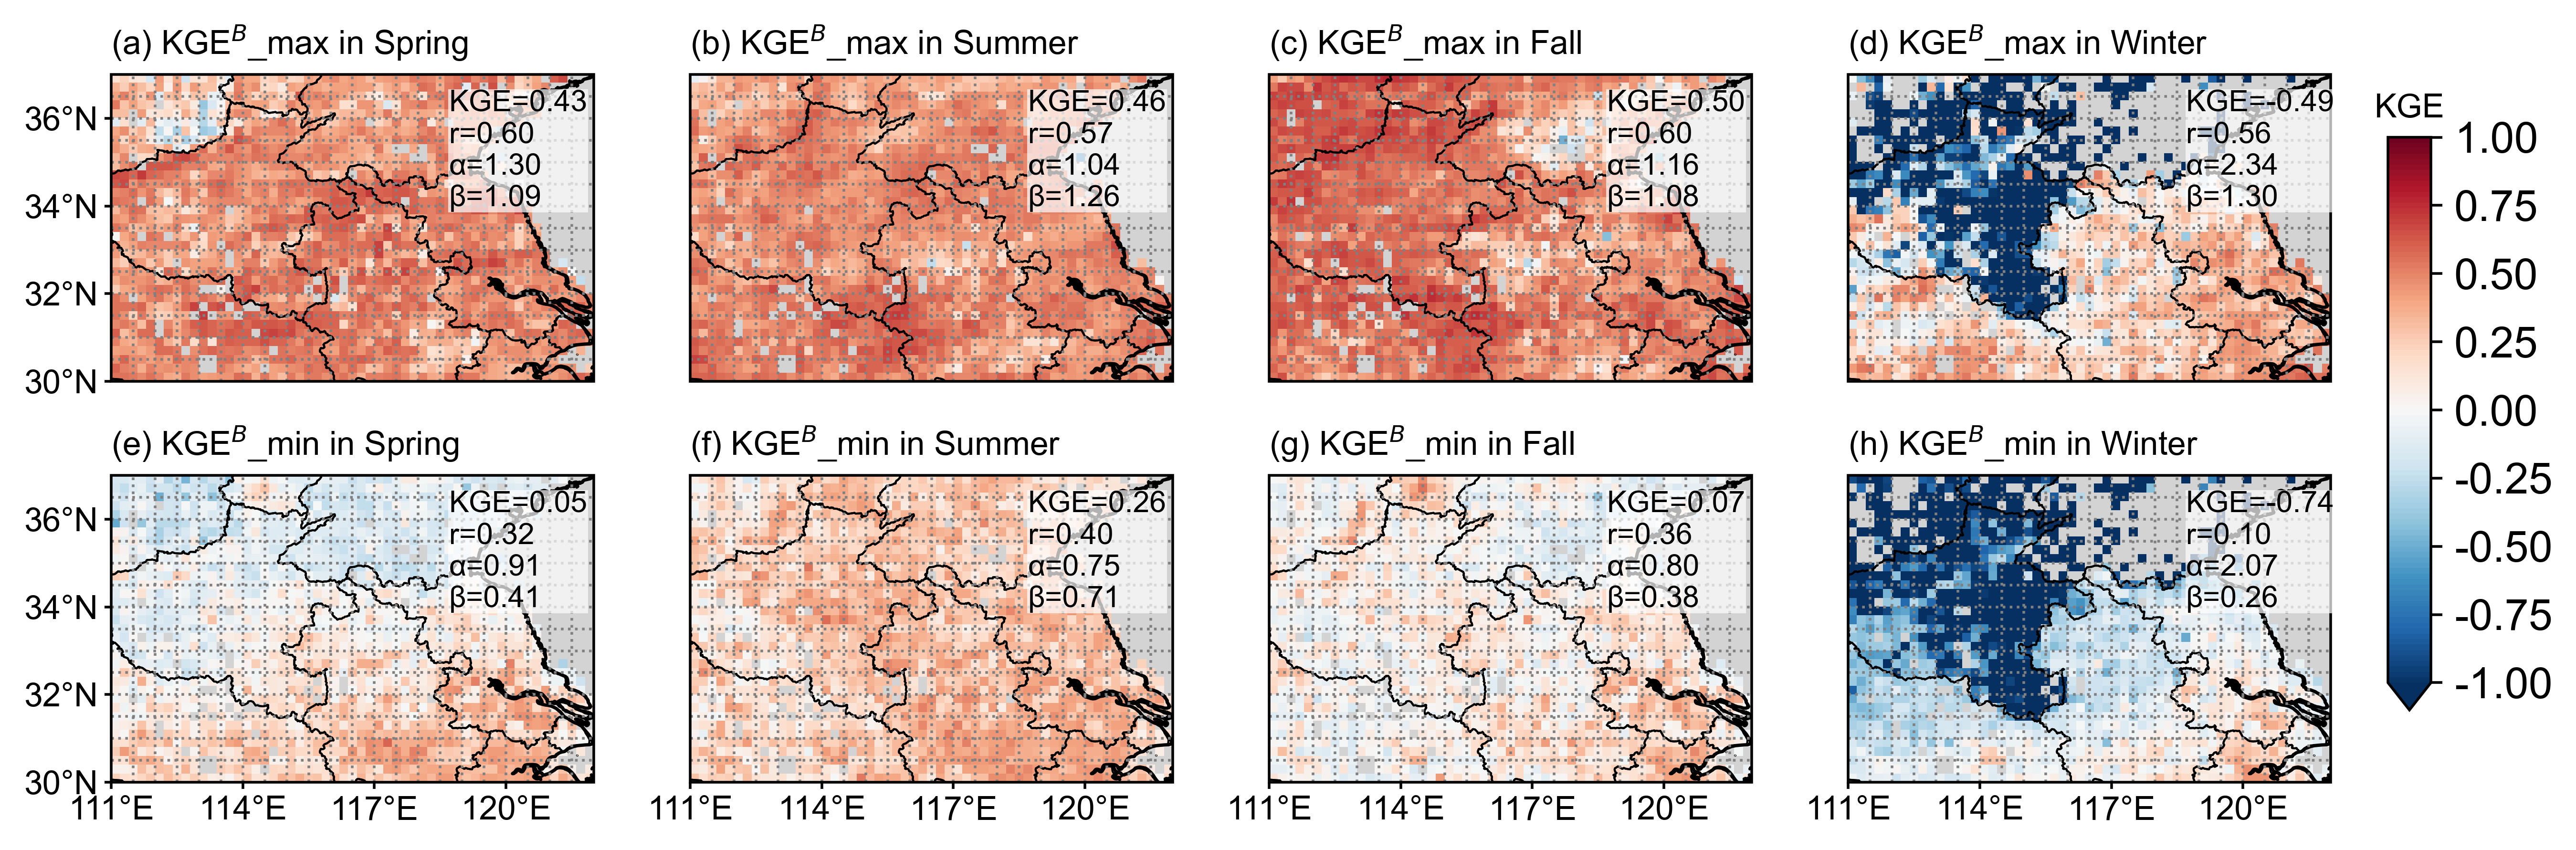

In [42]:

fig, axs = plt.subplots(2, 4, figsize=(12, 4), dpi=500,subplot_kw={'projection': ccrs.PlateCarree()}#,gridspec_kw={'hspace': 0.05 }#'wspace': 0.0,
                        )
axs=axs.ravel()
for i in range(8):
    ax = axs[i]
    ax.coastlines()
    
    ax.patch.set_facecolor("lightgrey") 
    provinces = ShapelyFeature(Reader(shp_path).geometries(), ccrs.PlateCarree(), edgecolor="k", facecolor="none")
    ax.add_feature(provinces, lw=0.6, zorder=2)
    
    ax.set_extent([111, 122, 30, 37], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.8, color="gray", linestyle=":")
    gl.top_labels, gl.bottom_labels, gl.right_labels, gl.left_labels = False, False, False, False
    gl.xlocator = mticker.FixedLocator(np.arange(111, 122, 0.5))
    gl.ylocator = mticker.FixedLocator(np.arange(30, 37, 0.5))
    
    if i==0 or i==4  :
        ax.set_yticks(np.arange(30, 38, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [4,5,6,7]  :
    # if i in [0,1,2,3]  :
        ax.set_xticks(np.arange(111, 123, 3), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [0,1,2,3]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap1,
            norm=norm1,
            origin="lower",
            extent=(111, 122, 30, 37),
        )
    if i in [4,5,6,7]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap1,
            norm=norm1,
            origin="lower",
            extent=(111, 122, 30, 37),
        )

    # 添加KGE、r、alpha、beta的平均值标注
    variant = 'max' if i < 4 else 'min'
    season_idx = i if i < 4 else i - 4
    annotation = (
        f"KGE={format_component(stats_for_plot[variant]['kge'][season_idx])}\n"
        f"r={format_component(stats_for_plot[variant]['r'][season_idx])}\n"
        f"α={format_component(stats_for_plot[variant]['alpha'][season_idx])}\n"
        f"β={format_component(stats_for_plot[variant]['beta'][season_idx])}"
    )
    ax.text(
        0.7,
        0.95,
        annotation,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2)
    )

    if i==3:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
        cbar=plt.colorbar (im,cax=cbar_ax,extend='min',orientation='vertical',ticks=np.arange(-1,1.25,0.25))
        font = {#'family' : 'serif',
                        #'color'  : 'darkred',
                        #'weight' : 'normal',
                        'size'   : 10,}
        cbar.ax.set_title('KGE',fontdict=font)
        cbar.ax.tick_params(labelsize=13)
        cbar.minorticks_off()

#plt.tight_layout()
# 修改标题，使用上标B表示考虑站点误差
axs[0].set_title('(a) KGE$^B$_max in Spring',fontsize=10,loc='left')
axs[1].set_title('(b) KGE$^B$_max in Summer',fontsize=10,loc='left')
axs[2].set_title('(c) KGE$^B$_max in Fall',fontsize=10,loc='left')
axs[3].set_title('(d) KGE$^B$_max in Winter',fontsize=10,loc='left')
axs[4].set_title('(e) KGE$^B$_min in Spring',fontsize=10,loc='left')
axs[5].set_title('(f) KGE$^B$_min in Summer',fontsize=10,loc='left')
axs[6].set_title('(g) KGE$^B$_min in Fall',fontsize=10,loc='left')
axs[7].set_title('(h) KGE$^B$_min in Winter',fontsize=10,loc='left')


plt.show()